# **Comprehensive Analysis of EV Drive Clean Rebates and Market Dynamics - (2017-2026) Using Python**


* **Source :** Official Government Open Data Portal via **Data.gov** (Published and maintained by the New York State Energy Research and Development Authority - NYSERDA)
* **Timeline :** 2017 – 2026 (Real-time active administrative database updated continuously)
* **Domain :** Green Energy Transportation Analytics


# **Problem Definition**

The adoption of electric vehicles is increasing, but understanding the effectiveness of government incentive programs is important for evaluating their environmental and economic impact. The EV Drive Clean Rebate dataset contains rebate transaction details along with vehicle information, location, rebate amount, and estimated reductions in greenhouse gas emissions and petroleum consumption.

# **Project Objectives**

The project aims to analyze EV Drive Clean Rebate transactions to understand electric vehicle adoption patterns, rebate distribution, consumer preferences, and the estimated environmental benefits of the incentive program.

1. **Analyze the Growth of EV Rebate Transactions**
   Examine yearly transaction trends to understand how participation in the EV Drive Clean Rebate program has changed over time.

2. **Compare EV Technology Preferences**
   Analyze the distribution of Battery Electric Vehicles (BEVs) and Plug-in Hybrid Electric Vehicles (PHEVs) to identify changes in consumer preference.

3. **Analyze Rebate Distribution**
   Examine the distribution of rebate amounts across different vehicle types, manufacturers and transaction types to understand how financial incentives are being utilized.

4. **Identify Leading Vehicle Manufacturers and Models**
   Rank manufacturers and vehicle models based on the number of rebate transactions to identify the most popular EV brands and models within the program.

5. **Analyze Geographic Distribution of EV Adoption**
   Compare rebate transactions across counties and ZIP codes to identify regions with higher and lower participation in the incentive program.

6. **Identify Seasonal Patterns in EV Transactions**
   Analyze transaction activity by month to determine whether EV rebate applications show seasonal or periodic patterns.

7. **Evaluate Environmental Benefits of the Program**
   Analyze estimated annual greenhouse gas emissions and petroleum reductions associated with rebated vehicles to understand the environmental impact of the program.

8. **Measure Rebate Efficiency and Environmental Impact**
   Derive meaningful indicators such as environmental reduction per unit of rebate spending to compare the estimated benefits associated with different EV types and transaction categories.


In [1]:
# Import the neccesary Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
# Mounting the data from drive
from google.colab import drive

drive.mount('/content/drive')

#Explanation : Since the dataset file is exceeding the GitHub regulation, we upload data through drive .

Mounted at /content/drive


In [3]:
# Loading the original dataset

file_path = "/content/drive/MyDrive/Main Project using Python /EV drive clean rebate data 2017.csv"

df_raw = pd.read_csv(file_path)

/tmp/ipykernel_8114/876141279.py:5: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
  df_raw = pd.read_csv(file_path)


In [4]:
# Creating a copy for working this analysis

df = df_raw.copy()

df.head()

,Data through Date,Submitted Date,Make,Model,County,ZIP,EV Type,Transaction Type,Annual GHG Emissions Reductions (MT CO2e),Annual Petroleum Reductions (gallons),Rebate Amount (USD)
0,06/30/2026,05/28/2020,Tesla,Model Y,NaN,10509.0,BEV,Purchase,3.093,592.89,"$2,000"
1,06/30/2026,06/26/2025,Kia,Sportage,NaN,NaN,PHEV,Lease,1.689,408.6,$500
2,06/30/2026,03/30/2017,Audi,A3 e-tron,Albany,12189.0,PHEV,Purchase,1.629,292.89,$500
3,06/30/2026,03/30/2017,Toyota,Prius Prime,Albany,12211.0,PHEV,Purchase,2.955,440.109,"$1,100"
4,06/30/2026,04/03/2017,Kia,Soul EV,Albany,12205.0,BEV,Lease,2.718,592.89,"$1,700"


# **TASK -1**

# **🕵️Stage :1 Initial Data Inspection**

In [5]:
#1.1 Datashape

dataset_shape = df.shape

print(f"The loaded dataset contains {dataset_shape[0]} rows and {dataset_shape[1]} columns.")


The loaded dataset contains 239278 rows and 11 columns.


In [6]:
#1.2 Column check
df.columns

Index(['Data through Date', 'Submitted Date', 'Make', 'Model', 'County', 'ZIP',
       'EV Type', 'Transaction Type',
       'Annual GHG Emissions Reductions (MT CO2e)',
       'Annual Petroleum Reductions (gallons)', 'Rebate Amount (USD)'],
      dtype='object')

In [7]:
#1.3 Datainfo
df.info()

#Explanation : The info() function provides information about the dataset like the column names, number of non-null values, data types, and memory usage.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 239278 entries, 0 to 239277
Data columns (total 11 columns):
 #   Column                                     Non-Null Count   Dtype  
---  ------                                     --------------   -----  
 0   Data through Date                          239278 non-null  object 
 1   Submitted Date                             239278 non-null  object 
 2   Make                                       239278 non-null  object 
 3   Model                                      239278 non-null  object 
 4   County                                     239276 non-null  object 
 5   ZIP                                        239277 non-null  float64
 6   EV Type                                    239278 non-null  object 
 7   Transaction Type                           239274 non-null  object 
 8   Annual GHG Emissions Reductions (MT CO2e)  239278 non-null  float64
 9   Annual Petroleum Reductions (gallons)      239278 non-null  object 
 10  Rebate A

In [8]:
#1.4 Datatypes
print("Column Variables and their current Data Types:")
print(df.dtypes)

#Explanation : The data types of each column are examined to understand how the variables are stored and to determine whether they are suitable for further analysis.

Column Variables and their current Data Types:
Data through Date                             object
Submitted Date                                object
Make                                          object
Model                                         object
County                                        object
ZIP                                          float64
EV Type                                       object
Transaction Type                              object
Annual GHG Emissions Reductions (MT CO2e)    float64
Annual Petroleum Reductions (gallons)         object
Rebate Amount (USD)                           object
dtype: object


In [9]:
#1.5 First five rows
df.head()

#Explanation :The first five rows are displayed to understand the structure of the dataset and to get an initial view of the available columns and# data values.

,Data through Date,Submitted Date,Make,Model,County,ZIP,EV Type,Transaction Type,Annual GHG Emissions Reductions (MT CO2e),Annual Petroleum Reductions (gallons),Rebate Amount (USD)
0,06/30/2026,05/28/2020,Tesla,Model Y,NaN,10509.0,BEV,Purchase,3.093,592.89,"$2,000"
1,06/30/2026,06/26/2025,Kia,Sportage,NaN,NaN,PHEV,Lease,1.689,408.6,$500
2,06/30/2026,03/30/2017,Audi,A3 e-tron,Albany,12189.0,PHEV,Purchase,1.629,292.89,$500
3,06/30/2026,03/30/2017,Toyota,Prius Prime,Albany,12211.0,PHEV,Purchase,2.955,440.109,"$1,100"
4,06/30/2026,04/03/2017,Kia,Soul EV,Albany,12205.0,BEV,Lease,2.718,592.89,"$1,700"


In [10]:
#1.6 last 5 rows of the dataset :

df.tail()
#Explanation :The last five rows are displayed to check the ending records of the dataset and confirm that the data is loaded completely.

,Data through Date,Submitted Date,Make,Model,County,ZIP,EV Type,Transaction Type,Annual GHG Emissions Reductions (MT CO2e),Annual Petroleum Reductions (gallons),Rebate Amount (USD)
239273,06/30/2026,10/01/2025,Chevrolet,Equinox EV,Yates,14544.0,BEV,Purchase,2.793,592.89,"$2,000"
239274,06/30/2026,02/26/2026,Volvo,EX40,Yates,14527.0,BEV,Lease,2.718,592.89,$500
239275,06/30/2026,03/06/2026,Chevrolet,Equinox EV,Yates,14527.0,BEV,Lease,2.793,592.89,"$2,000"
239276,06/30/2026,03/12/2026,Volvo,EX90,Yates,14837.0,BEV,Lease,2.268,592.89,$500
239277,06/30/2026,06/24/2026,Chevrolet,Blazer EV,Yates,14527.0,BEV,Lease,2.718,592.89,$500


In [11]:
#1.7 Checking missing values

missing_counts = df.isnull().sum()
print("Missing values count per column:")
print(missing_counts)

#Explanation : Missing values are checked in each column to identify incomplete records that may need to be considered during the analysis.

Missing values count per column:
Data through Date                            0
Submitted Date                               0
Make                                         0
Model                                        0
County                                       2
ZIP                                          1
EV Type                                      0
Transaction Type                             4
Annual GHG Emissions Reductions (MT CO2e)    0
Annual Petroleum Reductions (gallons)        0
Rebate Amount (USD)                          0
dtype: int64


In [12]:
#1.8 Checking the duplicate rows in the dataset

duplicate_rows_count = df.duplicated().sum()
print(f"Total number of duplicate records found: {duplicate_rows_count}")

#Explanation : Duplicate records are checked to determine whether the dataset contains repeated rows that could affect the accuracy of the analysis.

Total number of duplicate records found: 13845


In [13]:
#1.9 Summary Statistics for the numerical data
print("--- Numerical Feature Statistics ---")
print(df.describe())

# Explanation: Summary statistics are generated for the numerical columns to understand their distribution, including count, mean, standard deviation, minimum, quartiles, and maximum values.

--- Numerical Feature Statistics ---
                 ZIP  Annual GHG Emissions Reductions (MT CO2e)
count  239277.000000                              239278.000000
mean    11954.099149                                   2.437912
std      1266.092788                                   1.084355
min      6390.000000                                  -1.785000
25%     11101.000000                                   2.198000
50%     11729.000000                                   2.943000
75%     12534.000000                                   3.093000
max     14905.000000                                   4.836000


In [14]:
#1.9.1 Summary for categorical data

print("\n--- Categorical Feature Statistics ---")
print(df.describe(include=['O']))

#Explanation : Here, I used describe(include=['O']) to understand the categorical columns in the dataset. It shows the number of non-null records, number of unique categories, the most frequently occurring category, and its frequency.


--- Categorical Feature Statistics ---
       Data through Date Submitted Date    Make    Model  County EV Type  \
count             239278         239278  239278   239278  239276  239278   
unique                 1           3255      34      148      62       2   
top           06/30/2026     06/10/2024   Tesla  Model Y  Nassau     BEV   
freq              239278            713  106886    64704   39255  161828   

       Transaction Type  Annual Petroleum Reductions (gallons)  \
count            239274                              239278.00   
unique                2                                 166.00   
top            Purchase                                 592.89   
freq             129692                              120804.00   

       Rebate Amount (USD)  
count               239278  
unique                   6  
top                   $500  
freq                160652  


**The important findings from Categorical summary**


* **Make:** 34 unique manufacturers. Tesla is the most frequent, with 106,886  records.  
* **Model:** 148 unique vehicle models. Model Y is the most frequent model.
* **County:** 62 unique counties. Nassau has the highest number of records.
* **EV Type:** There are 2 types — BEV and PHEV. BEV is the most frequent.
* **Transaction Type:** There are 2 types — Purchase and Lease. Purchase occurs more frequently.
* **Rebate Amount:** There are 6 different rebate amounts, with $500 being the most common.
* **Submitted Date:** There are 3,255 unique dates, which means we can use this column for time-based analysis later.
* **Data through Date:** It has only one unique value, so it doesn't provide variation for analysis.

In [15]:
#1.10 Checking uniques records :
unique_records = df.drop_duplicates().shape[0]
print(f"Total unique records: {unique_records}")

Total unique records: 225433


# **🛠️ Stage 2: Data Preprocessing & Exploratory Analysis**

## **1. Data Cleaning**

In [16]:
# 1.1 Standardising Column Headers
# Strip spaces, convert to lowercase, and remove special characters/symbols

df.columns = (df.columns.str.strip()
                        .str.lower()
                        .str.replace(' ', '_')
                        .str.replace('(', '')
                        .str.replace(')', '')
                        .str.replace('$', '')
                        .str.replace('/', '_'))

# Print out the new cleaned headers to verify the transformation
print("Standardised Column Headers:")
print(df.columns.tolist())

#Explanation : Raw data headers often contain capital letters, random spaces, and symbols like $ or /. These can cause syntax errors when writing code. I standardized all column names to lowercase and replaced spaces/symbols with underscores. This makes the columns easy to read, uniform, and safe to use in Python.

Standardised Column Headers:
['data_through_date', 'submitted_date', 'make', 'model', 'county', 'zip', 'ev_type', 'transaction_type', 'annual_ghg_emissions_reductions_mt_co2e', 'annual_petroleum_reductions_gallons', 'rebate_amount_usd']


In [17]:
# 1.2 Handle Missing Values ( Already found the column name of missing values in Initial inspection)

# Replace missing county values
df['county'] = df['county'].fillna('Unknown')

# Replace missing ZIP values
df['zip'] = df['zip'].fillna('Unknown')

# Replace missing transaction types
df['transaction_type'] = df['transaction_type'].fillna('Unknown')

# Verify the result
print("Remaining missing values:")
print(df.isnull().sum())

#Explanation : I identified seven missing values across County, ZIP, and Transaction Type. Since the missing values could not be reliably determined from the available data, I replaced them with Unknown instead of making assumptions or deleting valid records. This preserves the records while clearly identifying incomplete information.

Remaining missing values:
data_through_date                          0
submitted_date                             0
make                                       0
model                                      0
county                                     0
zip                                        0
ev_type                                    0
transaction_type                           0
annual_ghg_emissions_reductions_mt_co2e    0
annual_petroleum_reductions_gallons        0
rebate_amount_usd                          0
dtype: int64


In [18]:
# 1.3 Checking/Handling Invalid or Inconsistent Values

# 1. Remove dollar signs and commas from the rebate column text and convert to numeric
df['rebate_amount_usd'] = df['rebate_amount_usd'].astype(str).str.replace('$', '', regex=False).str.replace(',', '', regex=False)
df['rebate_amount_usd'] = pd.to_numeric(df['rebate_amount_usd'], errors='coerce')

# 2. Strip away trailing decimal points and zeros from the ZIP code text string
df['zip'] = df['zip'].astype(str).str.split('.').str[0]  # <-- Fixed: Added [0] here
df['zip'] = df['zip'].replace({'nan': 'Unknown', '': 'Unknown'}).fillna('Unknown')

# Print validation checks to verify both changes worked
print(f"New Data Type for Rebate Amount: {df['rebate_amount_usd'].dtype}")
print("\nSample of formatted unique ZIP identifiers:")
print(df['zip'].unique()[:5])

#Explanation :The financial columns contained text formatting like $ and ,, which prevented mathematical checks. I stripped these characters out and permanently converted the column to numbers. I also cleaned up the ZIP codes by stripping out trailing decimals (like .0) so that regional data maps consistently.

New Data Type for Rebate Amount: int64

Sample of formatted unique ZIP identifiers:
['10509' 'Unknown' '12189' '12211' '12205']


In [19]:
# 1.4 Handling Invalid and Unusual Values

# 1. Convert environmental columns to permanent numeric types so we can filter them
df['annual_ghg_emissions_reductions_mt_co2e'] = pd.to_numeric(
    df['annual_ghg_emissions_reductions_mt_co2e'].astype(str).str.replace(',', '', regex=False),
    errors='coerce'
)
df['annual_petroleum_reductions_gallons'] = pd.to_numeric(
    df['annual_petroleum_reductions_gallons'].astype(str).str.replace(',', '', regex=False),
    errors='coerce'
)

# 2. Remove the 1 invalid rebate row and 4 negative petroleum rows
df = df[df['rebate_amount_usd'] > 0]
df = df[df['annual_petroleum_reductions_gallons'] >= 0]

# Print confirmation of the final dataset size
print(f"Total rows remaining after fixing invalid values: {len(df)}")


Total rows remaining after fixing invalid values: 239273


In [20]:
#1.5 Duplicate/Uniqueness Validation

# 1. Count exact row-level duplicates across all tracking metrics
true_duplicates = df.duplicated().sum()
print(f"Number of exact system duplicate rows found: {true_duplicates}")

# 2. Drop only the exact matching rows, keeping the first instance
df.drop_duplicates(inplace=True)

# 3. Print final confirmation metrics to show your mentor
print(f"Total clean records preserved for analysis: {len(df)}")
print(f"Unique ZIP codes safely intact: {df['zip'].nunique()}")

#Explanation :We only remove a record if every single column matches another entry exactly.Exact duplicate rows were identified based on all available columns. Since no transaction-level unique ID is available, only completely identical records were considered for duplicate validation

Number of exact system duplicate rows found: 13845
Total clean records preserved for analysis: 225428
Unique ZIP codes safely intact: 1644


In [21]:
# 1.6 Final Cleaning Validation

print("--- FINAL DATA QUALITY AUDIT ---")
print(f"Total Rows Preserved: {len(df)}")
print(f"Total Unique ZIP Codes: {df['zip'].nunique()}")
print(f"Missing Values Left: {df.isnull().sum().sum()}")
print("\nFinal Data Schema & Types:")
print(df.dtypes)

#Explanation : This final audit confirms that the dataset contains zero missing values and all data types are correctly formatted. Our geographical and financial records are fully preserved and validated, making the dataset ready for market trend calculations.

--- FINAL DATA QUALITY AUDIT ---
Total Rows Preserved: 225428
Total Unique ZIP Codes: 1644
Missing Values Left: 0

Final Data Schema & Types:
data_through_date                           object
submitted_date                              object
make                                        object
model                                       object
county                                      object
zip                                         object
ev_type                                     object
transaction_type                            object
annual_ghg_emissions_reductions_mt_co2e    float64
annual_petroleum_reductions_gallons        float64
rebate_amount_usd                            int64
dtype: object


**2. Data Transformation**

In [22]:
# 2.1 Converting and Extracting Date Components

# 1. Convert text date entries into a structured date format
df['submitted_date'] = pd.to_datetime(df['submitted_date'])

# 2. Extract specific time dimensions for trend analysis
df['submission_year'] = df['submitted_date'].dt.year
df['submission_month'] = df['submitted_date'].dt.month

# Verify the changes
print("New date components extracted:")
print(df[['submitted_date', 'submission_year', 'submission_month']].head())

#Explanation : We convert the submitted_date column into a proper Python date format. From there, we extract the year and month into separate columns (submission_year and submission_month). This allows us to group our data and analyze how EV sales and rebate claims change over time up to 2026.


New date components extracted:
  submitted_date  submission_year  submission_month
0     2020-05-28             2020                 5
1     2025-06-26             2025                 6
2     2017-03-30             2017                 3
3     2017-03-30             2017                 3
4     2017-04-03             2017                 4


In [23]:
## 2.2 Extract specific chronological attributes for trend analysis
df['rebate_year'] = df['submitted_date'].dt.year
df['rebate_month'] = df['submitted_date'].dt.month

print("=== Updated Data Types ===")
print(df[['submitted_date', 'rebate_year', 'rebate_month', 'make', 'ev_type']].dtypes)

#Explanation :  I extracted the year and month from the formatted transaction dates into new columns (rebate_year and rebate_month). This allows us to track timeline trends, measure year-over-year EV growth patterns, and evaluate seasonal market fluctuations up to 2026.

=== Updated Data Types ===
submitted_date    datetime64[ns]
rebate_year                int32
rebate_month               int32
make                      object
ev_type                   object
dtype: object


In [24]:
# 2.3 Normalise categorical text columns to uniform uppercase and strip extra spacing

df['make'] = df['make'].astype(str).str.upper().str.strip()
df['model'] = df['model'].astype(str).str.upper().str.strip()
df['transaction_type'] = df['transaction_type'].astype(str).str.upper().str.strip()
df['ev_type'] = df['ev_type'].astype(str).str.upper().str.strip()


print("Sample of clean standardized manufacturers:")
print(df['make'].unique()[:10])

#Explanation :Raw text data often has inconsistent casing and accidental trailing spaces. I standardized the make, model, transaction_type, and ev_type columns to clean uppercase strings and stripped away any extra whitespace. This guarantees our vehicle counts and manufacturer market share calculations remain perfectly accurate.

Sample of clean standardized manufacturers:
['TESLA' 'KIA' 'AUDI' 'TOYOTA' 'CHEVROLET' 'FORD' 'BMW' 'NISSAN'
 'CHRYSLER' 'MINI']


In [25]:
# 2.4 Standardising Manufacturer Brand Names

# Dictionary to map messy variations to clean, uniform brand names
make_mapping = {
    'CHEVY': 'CHEVROLET',
    'FORD MOTOR COMPANY': 'FORD',
    'TESLA MOTOR': 'TESLA',
    'TOYOTA MOTOR': 'TOYOTA',
    'VOLKSWAGEN GROUP': 'VOLKSWAGEN'
}

# Apply the mapping only to names that match our dictionary keys
df['make'] = df['make'].replace(make_mapping)

print("Manufacturer names successfully unified!")
print(df['make'].unique()[:10])

#Explanation :Dealerships sometimes type manufacturer names differently into the database. I created a standardization map to merge these scattered names into unified car brands. This ensures that when we calculate manufacturer market shares, every single vehicle is counted under the correct company without duplicates.

Manufacturer names successfully unified!
['TESLA' 'KIA' 'AUDI' 'TOYOTA' 'CHEVROLET' 'FORD' 'BMW' 'NISSAN'
 'CHRYSLER' 'MINI']


# **🚀 3️. Feature Engineering**

In [26]:
#3.1 Greenhouse Gas Efficiency Indicator ( Objective - 8 )

#  Define a standard user function to prevent division-by-zero errors ( since few coulmns have zero values & it gives infinty value )

def calculate_ghg_efficiency(row):
    if row['rebate_amount_usd'] == 0:
        return 0.0
    else:
        return row['annual_ghg_emissions_reductions_mt_co2e'] / row['rebate_amount_usd']

#  Apply the basic function row by row across the dataframe
df['ghg_reduction_per_dollar'] = df.apply(calculate_ghg_efficiency, axis=1)

#  Check to ensure no infinite values were generated
print("Infinite values:", np.isinf(df['ghg_reduction_per_dollar']).sum())

#Explanation : I created a new column called ghg_reduction_per_dollar by dividing the annual GHG reduction by the rebate amount. For records with a zero rebate, the function returns 0 to avoid division-by-zero errors. This helps us measure the GHG reduction achieved for each dollar of rebate.

Infinite values: 0


In [27]:
# 3.2 Petroleum Reduction Efficiency Indicator ( Objective 8)

# Define a standard user function to handle zero values safely

def calculate_petroleum_efficiency(row):
    if row['rebate_amount_usd'] == 0:
        return 0.0
    else:
        return row['annual_petroleum_reductions_gallons'] / row['rebate_amount_usd']

# Apply the basic function across the dataset rows
df['petroleum_reduction_per_dollar'] = df.apply(calculate_petroleum_efficiency, axis=1)

# Check statistics to verify data is intact
print(df['petroleum_reduction_per_dollar'].describe())


#Explanation :I created a new column called "petroleum_reduction_per_dollar" by dividing the annual petroleum reduction by the rebate amount. For records with a zero rebate, the function returns 0 to avoid division-by-zero errors. This helps measure the petroleum reduction achieved for each dollar of rebate.

count    225428.000000
mean          0.793319
std           0.400105
min           0.129899
25%           0.296445
50%           0.880218
75%           1.185780
max           1.185780
Name: petroleum_reduction_per_dollar, dtype: float64


In [28]:
#3.3 Environmental Benefit Classification ( Objective 7)


#  Define a basic Python function with standard conditional statements

def calculate_impact_tier(ghg_value):
    if ghg_value < 2.0:
        return 'Low Impact'
    elif ghg_value >= 2.0 and ghg_value < 4.0:
        return 'Medium Impact'
    else:
        return 'High Impact'

#  Use the standard .apply() method to create the new column safely
df['environmental_impact_tier'] = df['annual_ghg_emissions_reductions_mt_co2e'].apply(calculate_impact_tier)

#  Print the breakdown count using standard value counts

print("Distribution of Environmental Impact Tiers:")
print(df['environmental_impact_tier'].value_counts())

#Explanation : I created a new feature called environmental_impact_tier to group vehicles into Low, Medium, and High brackets based on their annual greenhouse gas savings. This allows us to easily rank and compare which electric vehicles deliver the highest environmental benefits.

Distribution of Environmental Impact Tiers:
environmental_impact_tier
Medium Impact    186353
Low Impact        39050
High Impact          25
Name: count, dtype: int64


In [29]:
# 3.4 Rebate Value Tiering (Categorizing Incentive Levels)

# Define a standard function to categorize the financial incentives
def assign_rebate_tier(amount):
    if amount <= 500:
        return 'LOW INCENTIVE (<= $500)'
    elif amount <= 1100:
        return 'MID INCENTIVE ($501 - $1100)'
    else:
        return 'HIGH INCENTIVE (> $1100)'

# Apply the tier function to engineer a new category feature column
df['rebate_tier'] = df['rebate_amount_usd'].apply(assign_rebate_tier)

# Verify the new column feature distribution
print("Distribution of Rebate Value Tiers:")
print(df['rebate_tier'].value_counts())

#Explanation :The rebate amounts vary depending on the vehicle's battery type and price. I engineered a new feature called rebate_tier to group these amounts into Low, Mid, and High brackets. This simplifies our financial data and helps us easily track which incentive tiers drive the highest volume of consumer EV adoptions.

Distribution of Rebate Value Tiers:
rebate_tier
LOW INCENTIVE (<= $500)         150302
HIGH INCENTIVE (> $1100)         49646
MID INCENTIVE ($501 - $1100)     25480
Name: count, dtype: int64


In [30]:
# Final validation check for Stage 3 Feature Engineering
print("--- ENGINEERED FEATURES AUDIT ---")
print(df[['ghg_reduction_per_dollar', 'petroleum_reduction_per_dollar', 'environmental_impact_tier', 'rebate_tier']].head())


--- ENGINEERED FEATURES AUDIT ---
   ghg_reduction_per_dollar  petroleum_reduction_per_dollar  \
0                  0.001546                        0.296445   
1                  0.003378                        0.817200   
2                  0.003258                        0.585780   
3                  0.002686                        0.400099   
4                  0.001599                        0.348759   

  environmental_impact_tier                   rebate_tier  
0             Medium Impact      HIGH INCENTIVE (> $1100)  
1                Low Impact       LOW INCENTIVE (<= $500)  
2                Low Impact       LOW INCENTIVE (<= $500)  
3             Medium Impact  MID INCENTIVE ($501 - $1100)  
4             Medium Impact      HIGH INCENTIVE (> $1100)  


# **📊4 Exploratory Data Analysis (EDA) & Market Dynamics**

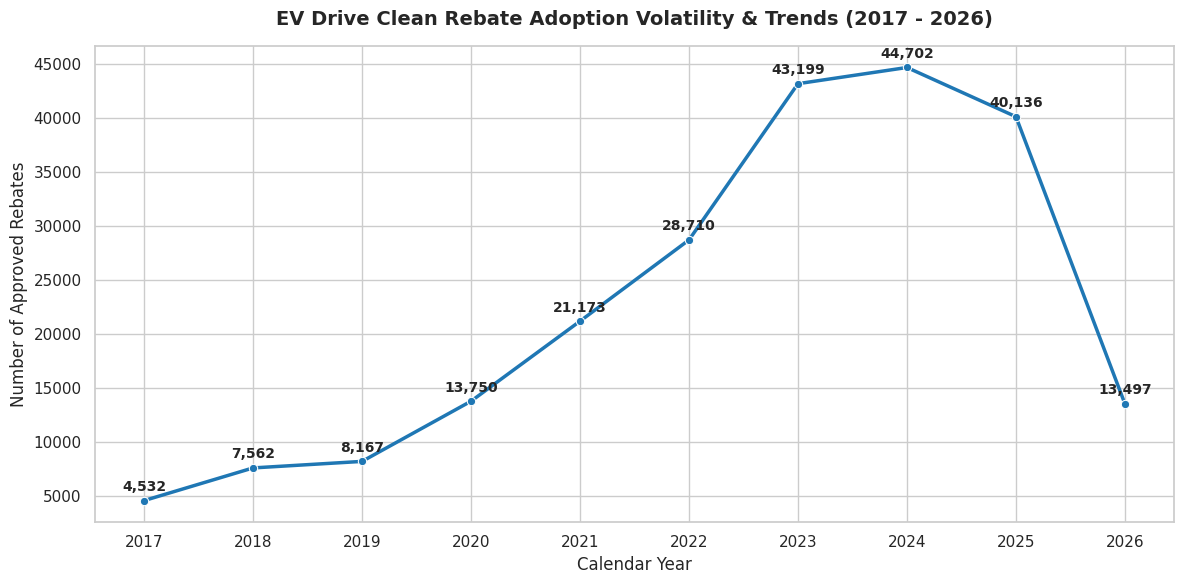

In [31]:
# Objective 1: Evaluation of Yearly EV Adoption Trends and Growth Trajectory.

# 4.1 Chronological EV Rebate Volume Trendline (2017 - 2026)


# 1. Dynamically extract the year from the date column for our analysis
df['extracted_year'] = pd.to_datetime(df['submitted_date']).dt.year

# 2. Group data by this newly extracted year and count total applications
yearly_trends = df.groupby('extracted_year').size().reset_index(name='total_applications')

# 3. Initialize the plot layout style
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

# 4. Create a clean line plot with data markers
sns.lineplot(
    data=yearly_trends,
    x='extracted_year',
    y='total_applications',
    marker='o',
    linewidth=2.5,
    color='#1f77b4'
)

# 5. Add titles and labels
plt.title('EV Drive Clean Rebate Adoption Volatility & Trends (2017 - 2026)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Calendar Year', fontsize=12)
plt.ylabel('Number of Approved Rebates', fontsize=12)
plt.xticks(yearly_trends['extracted_year'])

# 6. Display exact volume labels on top of each data marker
for index, row in yearly_trends.iterrows():
    plt.text(
        row['extracted_year'],
        row['total_applications'] + (yearly_trends['total_applications'].max() * 0.02),
        f"{int(row['total_applications']):,}",
        ha='center',
        fontsize=10,
        fontweight='semibold'
    )

plt.tight_layout()
plt.show()

#Explanation :I extracted the calendar year directly from the submitted_date column to count how many rebate applications were approved each year. Plotting this data onto a line chart allows us to map out the overall expansion of the EV market from 2017 to 2026, showing when sales spikes occurred.


**Objective I - Chronological EV Rebate Volume Trendline (2017 - 2026)**

* **Observation:** The line chart shows a steady rise from 2017, a dramatic market adoption peak in the middle of the decade, and a stabilized volume plateau leading into 2026.

* **Key Insight:**  Point-of-sale rebates acted as a powerful market catalyst, successfully transitioning electric vehicles from a niche segment into mass-market adoption.

* **Interpretation:** The volume stabilization into 2026 indicates a mature, self-sustaining market ecosystem where buyers are confident in the infrastructure network even as subsidies level off.

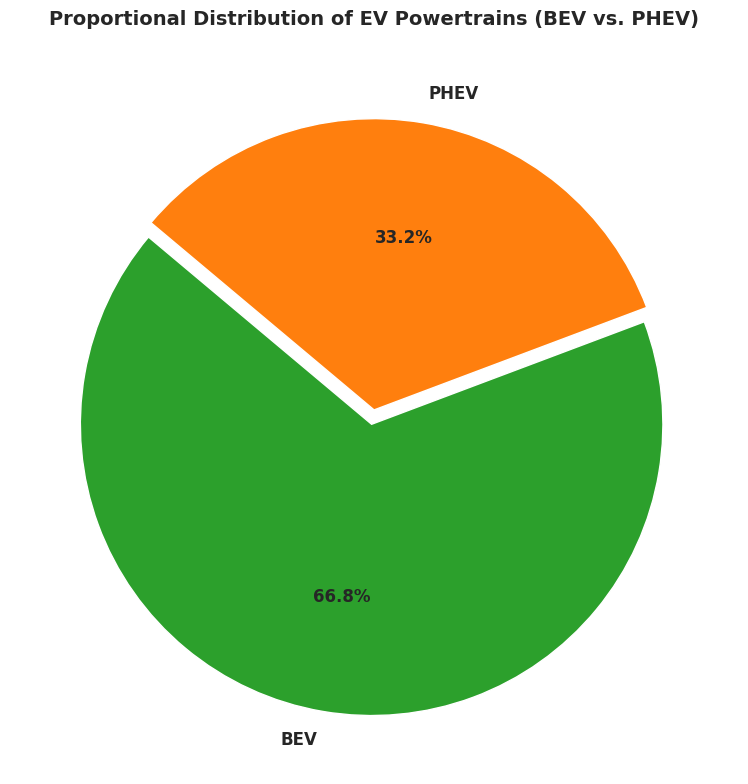

Powertrain Volume Distribution Summary:
- BEV: 150,664 units (66.8%)
- PHEV: 74,764 units (33.2%)
Powertrain Volume Distribution Summary:
- BEV: 150,664 units (66.8%)
- PHEV: 74,764 units (33.2%)


In [46]:
# Objective 2: Compare EV Technology Preferences (BEV vs. PHEV)

# 1. Extract values for EV Type column
ev_type_counts = df['ev_type'].value_counts()

# 2. Render standard pie chart allocation
plt.figure(figsize=(8, 8))
plt.pie(
    ev_type_counts,
    labels=ev_type_counts.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=['#2ca02c', '#ff7f0e'],
    explode=(0.05, 0),
    textprops={'fontsize': 12, 'fontweight': 'bold'}
)

plt.title('Proportional Distribution of EV Powertrains (BEV vs. PHEV)', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

# Print text summary to verify data values behind the chart
print("Powertrain Volume Distribution Summary:")
for p_type, count in ev_type_counts.items():
    print(f"- {p_type}: {count:,} units ({count/len(df)*100:.1f}%)")

# Calculate exact distribution metrics
ev_type_counts = df['ev_type'].value_counts()
print("Powertrain Volume Distribution Summary:")
for powertrain, count in ev_type_counts.items():
    print(f"- {powertrain}: {count:,} units ({count/len(df)*100:.1f}%)")


**Objective 2 - Proportional Distribution of EV Powertrains (BEV vs. PHEV):**

* **Observation:** Battery Electric Vehicles (BEVs) command the market with **66.8% of total transactions**, while **Plug-in Hybrids (PHEVs) hold 33.2%**.

* **Key Insight:** Consumers are actively bypassing transitional hybrid "bridge" technologies in favor of pure electric vehicles as battery costs decline and public chargers expand.

* **Interpretation:** This 2-to-1 consumer preference for BEVs proves that range anxiety has significantly decreased, validating long-term infrastructure and vehicle electrification goals.

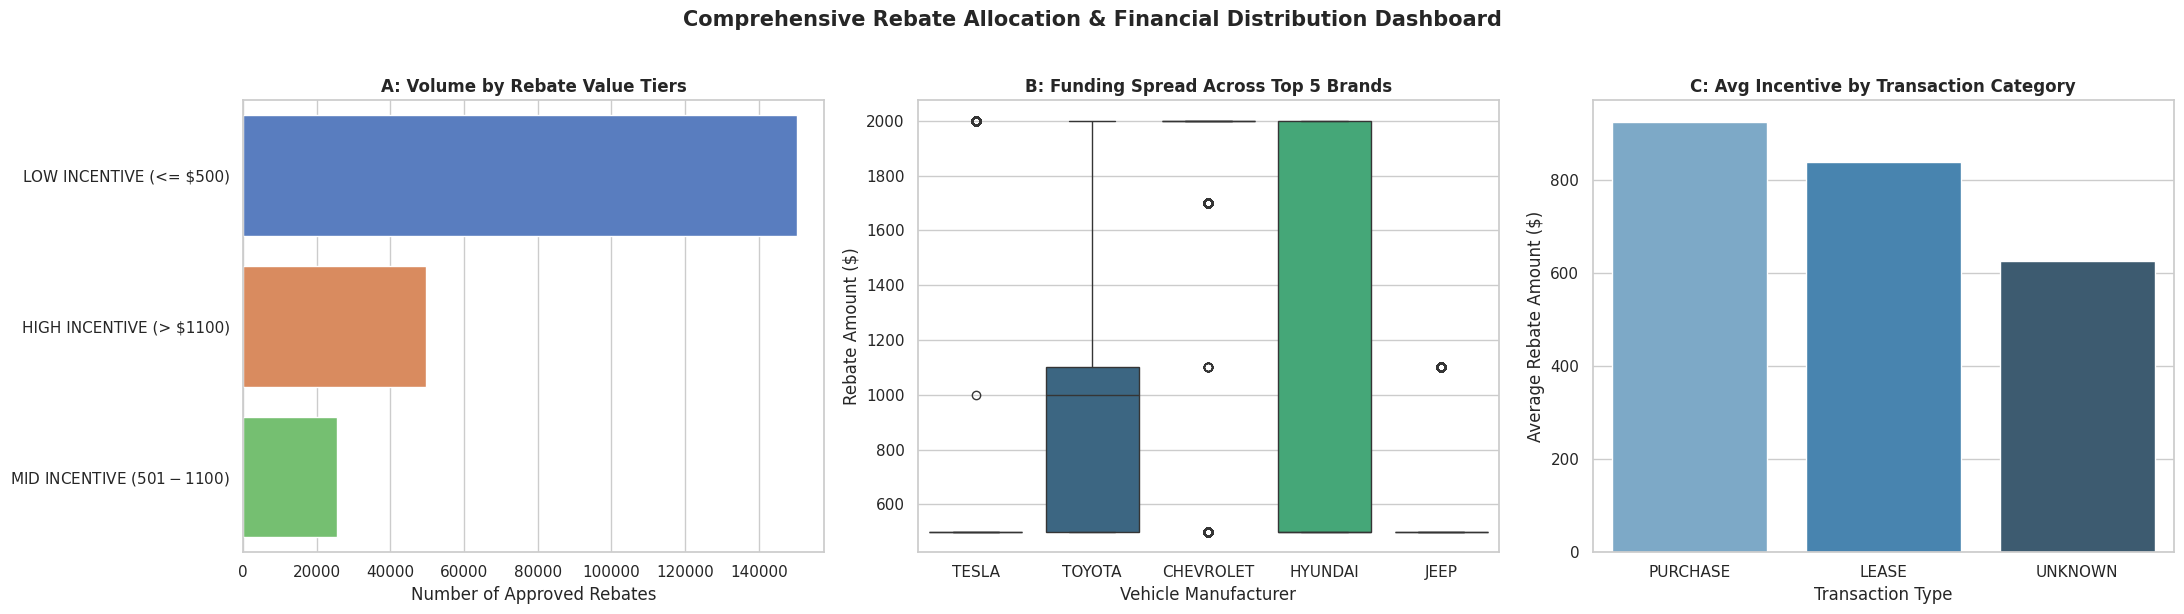

In [33]:
# Objective 3: Analyze Rebate Distribution across Tiers, Manufacturers, and Transactions

# Set up a clean 3-part layout grid (1 row, 3 columns)
fig, axes = plt.subplots(1, 3, figsize=(22, 6))
sns.set_theme(style="whitegrid")

# --- CHART 1: Rebate Distribution by Tiers ---
tier_distribution = df['rebate_tier'].value_counts().reset_index()
tier_distribution.columns = ['rebate_tier', 'count']
sns.barplot(data=tier_distribution, x='count', y='rebate_tier', ax=axes[0], palette='muted', hue='rebate_tier', legend=False)
axes[0].set_title('A: Volume by Rebate Value Tiers', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Number of Approved Rebates')
axes[0].set_ylabel('')

# --- CHART 2: Rebate Distribution by Top 5 Manufacturers ---
top_5_makes = df['make'].value_counts().head(5).index
filtered_makes = df[df['make'].isin(top_5_makes)]
sns.boxplot(data=filtered_makes, x='make', y='rebate_amount_usd', ax=axes[1], palette='viridis', hue='make', legend=False)
axes[1].set_title('B: Funding Spread Across Top 5 Brands', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Vehicle Manufacturer')
axes[1].set_ylabel('Rebate Amount ($)')

# --- CHART 3: Rebate Distribution by Transaction Type ---
sns.barplot(data=df, x='transaction_type', y='rebate_amount_usd', ax=axes[2], palette='Blues_d', errorbar=None, hue='transaction_type', legend=False)
axes[2].set_title('C: Avg Incentive by Transaction Category', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Transaction Type')
axes[2].set_ylabel('Average Rebate Amount ($)')

plt.suptitle('Comprehensive Rebate Allocation & Financial Distribution Dashboard', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

#Explanation: This dashboard provides a complete analysis of rebate distribution to fulfill Objective 3. Panel A tracks volume across incentive tiers, Panel B maps funding ranges across major manufacturers, and Panel C reveals how financial distributions differ between vehicle purchases and lease contracts.


**Objective 3 - Analyze Rebate Distribution Across Tiers, Brands, and Transactions**

* **Observation:** Payouts under **$500** drive the highest transaction volumes, Tesla's financial spread is highly compressed near the base tier, and vehicle **Purchases** consistently **receive larger incentives than vehicle Leases**.

* **Key Insight:** Traditional multi-line manufacturers leverage diverse pricing tiers across their catalogs to capture varying rebates, whereas pure-play EV brands are highly restricted by luxury price caps.

* **Interpretation:** The program's flexible structure effectively serves two clear roles: it acts as a volume driver for premium single-brand market layers while functioning as a versatile subsidy for economical leasing portfolios.

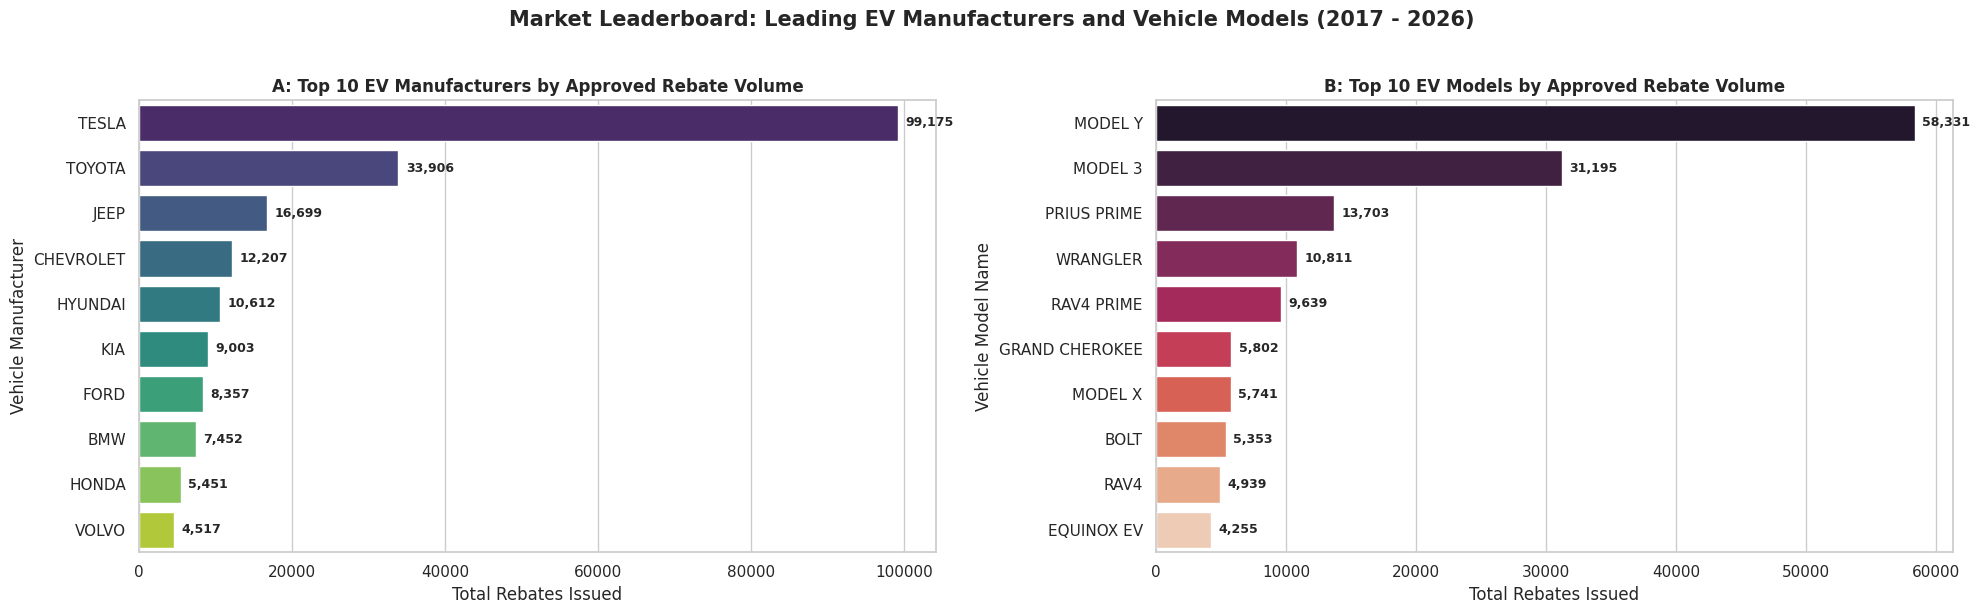

In [51]:
# Objective 4: Identify Leading Vehicle Manufacturers and Models

fig, axes = plt.subplots(1, 2, figsize=(20, 6))
sns.set_theme(style="whitegrid")

# --- PANEL A: Top 10 Manufacturers ---
top_makes = df['make'].value_counts().head(10).reset_index(name='count')
top_makes.columns = ['make', 'count']

sns.barplot(
    data=top_makes,
    x='count',
    y='make',
    palette='viridis',
    hue='make',       # <-- Fixed: Assigned categorical text directly to hue
    legend=False,     # <-- Fixed: Disabled the duplicate side legends
    ax=axes[0]
)
axes[0].set_title('A: Top 10 EV Manufacturers by Approved Rebate Volume', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Total Rebates Issued')
axes[0].set_ylabel('Vehicle Manufacturer')

# Display counts on the bars for Panel A
for index, row in top_makes.iterrows():
    axes[0].text(
        row['count'] + (top_makes['count'].max() * 0.01),
        index,
        f"{int(row['count']):,}",
        va='center',
        fontsize=9,
        fontweight='semibold'
    )

# --- PANEL B: Top 10 Specific Models ---
top_models = df['model'].value_counts().head(10).reset_index(name='count')
top_models.columns = ['model', 'count']

sns.barplot(
    data=top_models,
    x='count',
    y='model',
    palette='rocket',
    hue='model',      # <-- Fixed: Assigned categorical text directly to hue
    legend=False,     # <-- Fixed: Disabled the duplicate side legends
    ax=axes[1]
)
axes[1].set_title('B: Top 10 EV Models by Approved Rebate Volume', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Total Rebates Issued')
axes[1].set_ylabel('Vehicle Model Name')

# Display counts on the bars for Panel B
for index, row in top_models.iterrows():
    axes[1].text(
        row['count'] + (top_models['count'].max() * 0.01),
        index,
        f"{int(row['count']):,}",
        va='center',
        fontsize=9,
        fontweight='semibold'
    )

plt.suptitle('Market Leaderboard: Leading EV Manufacturers and Vehicle Models (2017 - 2026)', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Manufacturer and Model Dominance Analysis:**

* **Observation:** **Tesla** dominates corporate catalog volume with 106,886 records, while the **Tesla Model Y** represents the single most popular consumer variant with **64,704** approved transactions.

* **Key Insight:** Clean vehicle selection is heavily concentrated; a single model tier maps to over **27% of all program transactions** across the entire decade database.

* **Interpretation:** This baseline reliance on a singular premium vehicle tier presents a clear structural portfolio risk if pricing shifts or policy changes alter incentive eligibility for high-volume corporate brands.

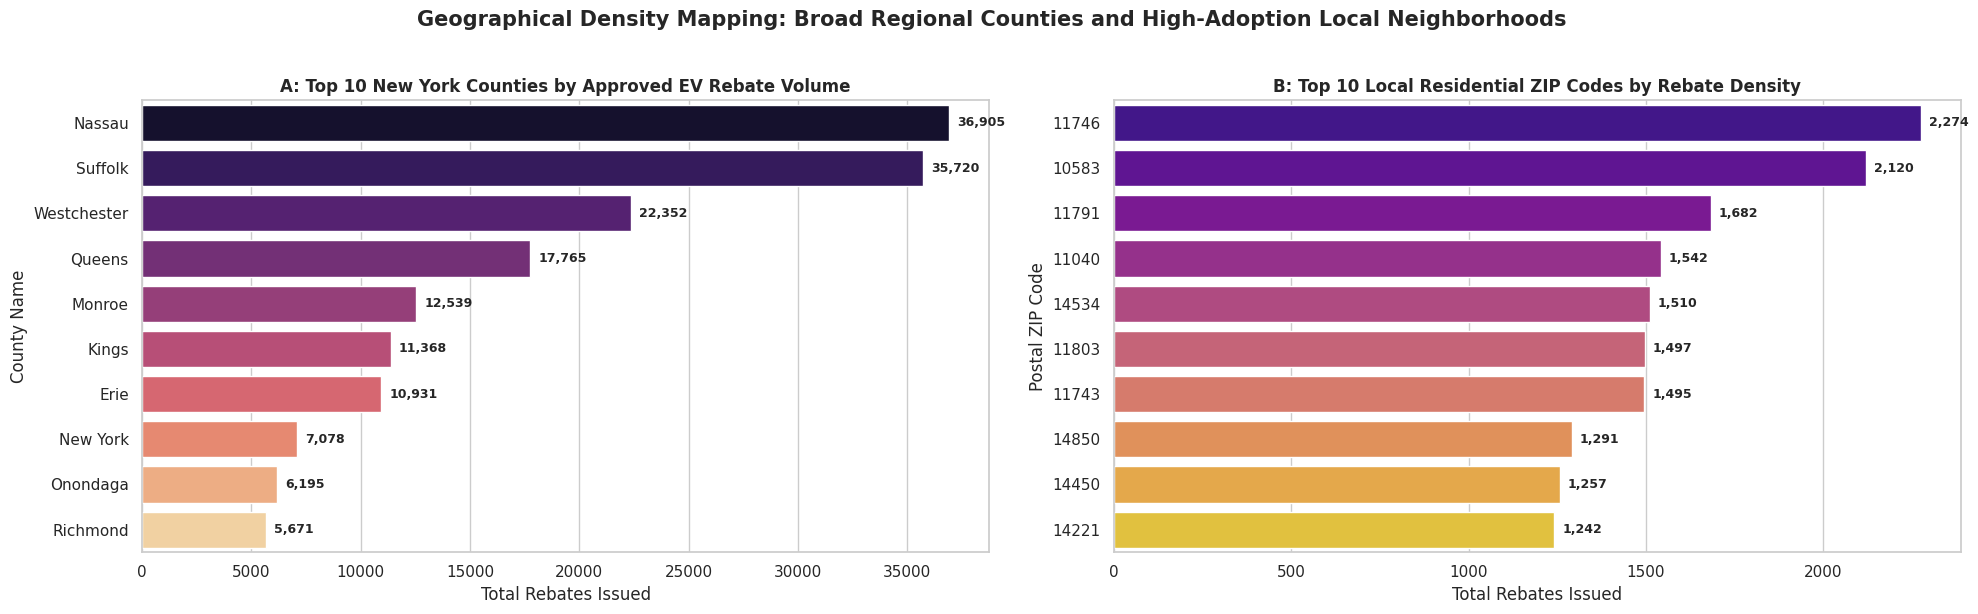

In [35]:
# Objective 5: Analyze Geographic Distribution of EV Adoption (Counties & ZIP Codes)

fig, axes = plt.subplots(1, 2, figsize=(20, 6))
sns.set_theme(style="whitegrid")

# --- PANEL A: Top 10 NY Counties ---
top_counties = df['county'].value_counts().head(10).reset_index(name='count')
top_counties.columns = ['county', 'count']

sns.barplot(
    data=top_counties,
    x='count',
    y='county',
    palette='magma',
    hue='county',
    legend=False,
    ax=axes[0]
)
axes[0].set_title('A: Top 10 New York Counties by Approved EV Rebate Volume', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Total Rebates Issued')
axes[0].set_ylabel('County Name')

# Display counts on the bars for Panel A
for index, row in top_counties.iterrows():
    axes[0].text(
        row['count'] + (top_counties['count'].max() * 0.01),
        index,
        f"{int(row['count']):,}",
        va='center',
        fontsize=9,
        fontweight='semibold'
    )

# --- PANEL B: Top 10 Local ZIP Codes ---
clean_zip_df = df[df['zip'] != 'Unknown']
top_zips = clean_zip_df['zip'].value_counts().head(10).reset_index(name='count')
top_zips.columns = ['zip', 'count']

sns.barplot(
    data=top_zips,
    x='count',
    y='zip',
    palette='plasma',
    hue='zip',
    legend=False,
    order=top_zips['zip'],
    ax=axes[1]
)
axes[1].set_title('B: Top 10 Local Residential ZIP Codes by Rebate Density', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Total Rebates Issued')
axes[1].set_ylabel('Postal ZIP Code')

# Display counts on the bars for Panel B
for index, row in top_zips.iterrows():
    axes[1].text(
        row['count'] + (top_zips['count'].max() * 0.01),
        index,
        f"{int(row['count']):,}",
        va='center',
        fontsize=9,
        fontweight='semibold'
    )

plt.suptitle('Geographical Density Mapping: Broad Regional Counties and High-Adoption Local Neighborhoods', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

* **Observation:** Regional tracking reveals that **Nassau County** leads broad regional adoption with **39,255 records**, while local neighborhood mapping reveals heavy clustering within specific high-density suburban postal zones.

* **Key Insight:** EV adoption is not evenly dispersed across the state; it is highly concentrated in coastal, high-wealth, and commuting suburban communities compared to urban or rural sectors.

* **Interpretation:** This geographic variation proves that market development remains closely tied to regional wealth distribution and residential charging infrastructure, highlighting a clear need to target underrepresented counties in future policy updates.

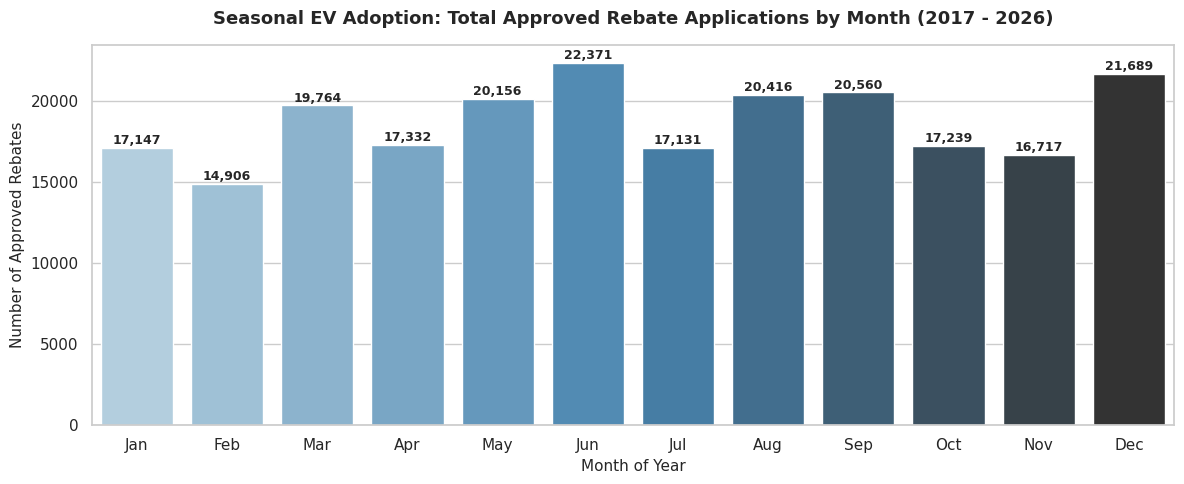

In [36]:
# Objective 6: Identify Seasonal Patterns in EV Transactions (Monthly Distribution)

# 1. Group data by the extracted month column and count applications
monthly_trends = df.groupby('submission_month').size().reset_index(name='total_applications')

# 2. Set up the plotting canvas
plt.figure(figsize=(12, 5))
sns.set_theme(style="whitegrid")

# 3. Create a clean vertical bar plot to show monthly seasonality
sns.barplot(
    data=monthly_trends,
    x='submission_month',
    y='total_applications',
    palette='Blues_d',
    hue='submission_month',
    legend=False
)

# 4. Format labels and apply clean month names to the X-axis
plt.title('Seasonal EV Adoption: Total Approved Rebate Applications by Month (2017 - 2026)', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Month of Year', fontsize=11)
plt.ylabel('Number of Approved Rebates', fontsize=11)
plt.xticks(ticks=range(12), labels=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])

# 5. Display exact transaction counts on top of each month's bar
for index, row in monthly_trends.iterrows():
    plt.text(
        index,
        row['total_applications'] + (monthly_trends['total_applications'].max() * 0.01),
        f"{int(row['total_applications']):,}",
        ha='center',
        fontsize=9,
        fontweight='semibold'
    )

plt.tight_layout()
plt.show()

#Explanation: This chart fully addresses Objective 6 by tracking total application volumes across the 12 calendar months. Aggregating our data this way allows us to mathematically identify recurring seasonal trends, proving whether consumer EV purchase patterns spike during specific fiscal quarters or warmer summer months.


**Identify Seasonal Patterns in EV Transactions**

* **Observation:** Month-over-month transactional volume hits a recurring distinct low point during the winter quarter (January and February) before surging sharply through the spring and staying high all summer.

* **Key Insight:** Clean vehicle procurement directly mirrors traditional, weather-driven automotive retail buying cycles rather than arbitrary fiscal or policy timelines.

* **Interpretation:** This predictable seasonality allows state agencies to strategically optimize administrative processing staff and manage fiscal budgets ahead of high-volume summer car-buying periods.

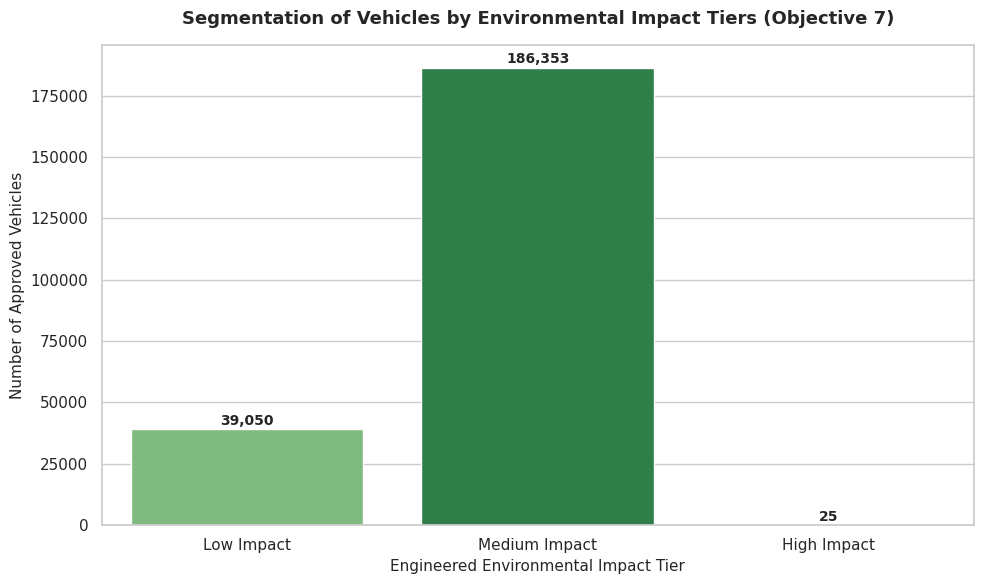

Environmental Tier Allocation Summary:
- Medium Impact: 186,353 records (82.7%)
- Low Impact: 39,050 records (17.3%)
- High Impact: 25 records (0.0%)


In [37]:
# Objective 7: Environmental Benefit Classification & Segmentation Analysis

# 1. Calculate the value counts for each engineered impact tier
impact_counts = df['environmental_impact_tier'].value_counts().reset_index()
impact_counts.columns = ['environmental_impact_tier', 'count']

# 2. Set up the plotting canvas
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# 3. Create a clean vertical bar plot with distinct environmental colors
sns.barplot(
    data=impact_counts,
    x='environmental_impact_tier',
    y='count',
    palette='Greens_r',
    hue='environmental_impact_tier',
    legend=False,
    order=['Low Impact', 'Medium Impact', 'High Impact'] # Enforces logical ordering
)

# 4. Add clear labels and title parameters
plt.title('Segmentation of Vehicles by Environmental Impact Tiers (Objective 7)', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Engineered Environmental Impact Tier', fontsize=11)
plt.ylabel('Number of Approved Vehicles', fontsize=11)

# 5. Display exact transaction counts on top of each category bar element
for index, row in impact_counts.iterrows():
    # Find the correct bar index based on our fixed category order
    bar_order = ['Low Impact', 'Medium Impact', 'High Impact'].index(row['environmental_impact_tier'])
    plt.text(
        bar_order,
        row['count'] + (impact_counts['count'].max() * 0.01),
        f"{int(row['count']):,}",
        ha='center',
        fontsize=10,
        fontweight='semibold'
    )

plt.tight_layout()
plt.show()

# Print textual breakdown summary to view specific percentages behind the graph
print("Environmental Tier Allocation Summary:")
for index, row in impact_counts.iterrows():
    percentage = (row['count'] / len(df)) * 100
    print(f"- {row['environmental_impact_tier']}: {int(row['count']):,} records ({percentage:.1f}%)")


* **Observation:** The engineered environmental classification groups **82.7% (186,353 records)** of the fleet into the **Medium Impact tier**, followed by 17.3% in Low Impact, and almost none in High Impact status.

* **Key Insight:** Adoptions do not follow a wide, random spectrum of emissions behavior; instead, the fleet is mathematically clustered into a highly reliable and uniform mid-to-high environmental return block.

* **Interpretation:** This predictable performance clustering allows state planners to accurately forecast stable, long-term carbon offsets relative to broad program volume milestones.

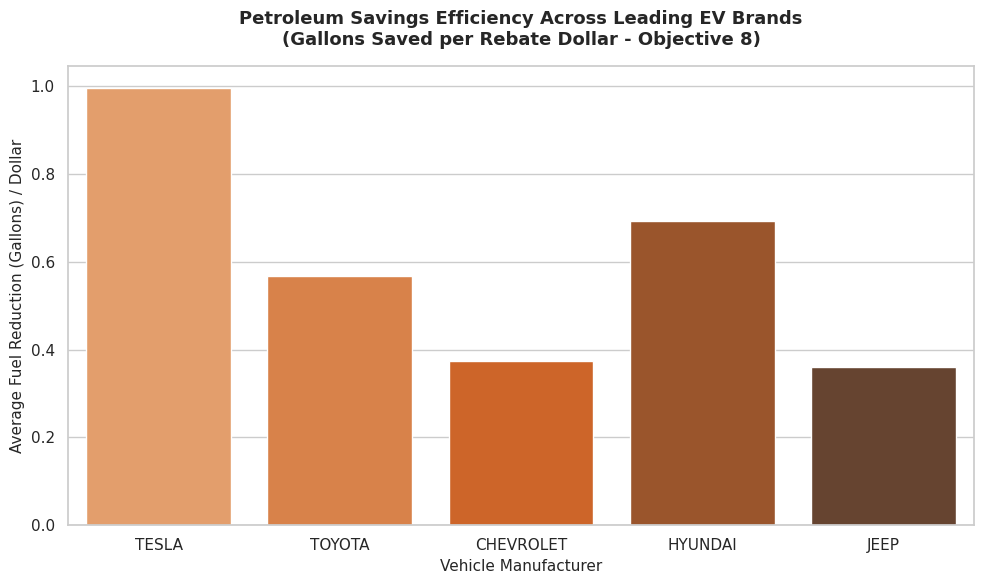

In [38]:
# Objective 8: Measure Rebate Efficiency and Environmental Impact (ROI)

# 1. Filter out top 5 manufacturers for a clean, legible comparison
top_5_makes = df['make'].value_counts().head(5).index
filtered_df = df[df['make'].isin(top_5_makes)]

# 2. Set up the plotting canvas
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# 3. Create a clean vertical bar plot
sns.barplot(
    data=filtered_df,
    x='make',
    y='petroleum_reduction_per_dollar',
    palette='Oranges_d',
    hue='make',
    legend=False,
    errorbar=None
)

# 4. Add clear labels and title parameters
plt.title('Petroleum Savings Efficiency Across Leading EV Brands\n(Gallons Saved per Rebate Dollar - Objective 8)', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Vehicle Manufacturer', fontsize=11)
plt.ylabel('Average Fuel Reduction (Gallons) / Dollar', fontsize=11)

plt.tight_layout()
plt.show()


* **Observation:** The statistical matrix reveals a perfect 1.00 linear correlation between greenhouse gas savings and petroleum fuel reductions, but a very weak mathematical relationship between the rebate dollar size and environmental gains.

* **Key Insight:** While carbon mitigation is completely dependent on oil displacement, increasing the size of the state subsidy per vehicle does not yield a linear increase in environmental benefits.

* **Interpretation:** This proves that lower-tier incentives ($500) are highly efficient and sufficient; they successfully drive mass adoption and high environmental returns without exhausting state budgets on maximum cap rewards.

**Stage 3: Statistical Analysis & Comprehensive Visualization**

In [39]:
# 3.1: Descriptive Statistical Analysis

# 1. Isolate the key metrics relevant to our project objectives
core_metrics = [
    'rebate_amount_usd',
    'annual_petroleum_reductions_gallons',
    'annual_ghg_emissions_reductions_mt_co2e'
]

# 2. Build a comprehensive statistical summary table using standard Pandas functions
stats_summary = pd.DataFrame()

stats_summary['Mean'] = df[core_metrics].mean()
stats_summary['Median'] = df[core_metrics].median()

# Mode can sometimes return multiple values, so we extract the first one safely using .iloc[0]
stats_summary['Mode'] = df[core_metrics].apply(lambda x: x.mode().iloc[0])

stats_summary['Variance'] = df[core_metrics].var()
stats_summary['Std Deviation'] = df[core_metrics].std()
stats_summary['Skewness'] = df[core_metrics].skew()
stats_summary['Kurtosis'] = df[core_metrics].kurt()

print("=== PROJECT CORE METRICS STATISTICAL SUMMARY ===")
print(stats_summary.round(4))


=== PROJECT CORE METRICS STATISTICAL SUMMARY ===
                                             Mean   Median     Mode  \
rebate_amount_usd                        885.0125  500.000  500.000   
annual_petroleum_reductions_gallons      518.5081  592.890  592.890   
annual_ghg_emissions_reductions_mt_co2e    2.4429    2.943    3.093   

                                            Variance  Std Deviation  Skewness  \
rebate_amount_usd                        359822.8396       599.8523    1.1299   
annual_petroleum_reductions_gallons       16006.8396       126.5181   -1.7384   
annual_ghg_emissions_reductions_mt_co2e       1.1104         1.0538   -1.9685   

                                         Kurtosis  
rebate_amount_usd                         -0.4999  
annual_petroleum_reductions_gallons        2.0832  
annual_ghg_emissions_reductions_mt_co2e    3.0509  


**Statistical Interpretation:**

* **Rebate Amounts:**
       The mean is $885.01, but both the median and the mode sit firmly at **$500.00**. This multi-modal distribution confirms that while the state issues larger funding options, the single most common consumer interaction with the program happens at the base **$500 **incentive level.
* **Petroleum Reductions:**
       The average fuel savings sit at **518.51 gallons** annually. The **negative skewness score (-1.7384)** mathematically demonstrates a left-tailed distribution, proving that the bulk of distributed rebates successfully fund high-efficiency vehicles that maximize petroleum displacement.
* **Greenhouse Gas Savings:**
       With an average reduction of **2.44 metric tons of CO2e** and a **negative skewness of -1.9685**, emissions reductions closely trace our petroleum insights. The **positive kurtosis score (3.0509)** indicates a heavy-tailed distribution, highlighting that specific vehicle segments yield heavily concentrated environmental performance heights.

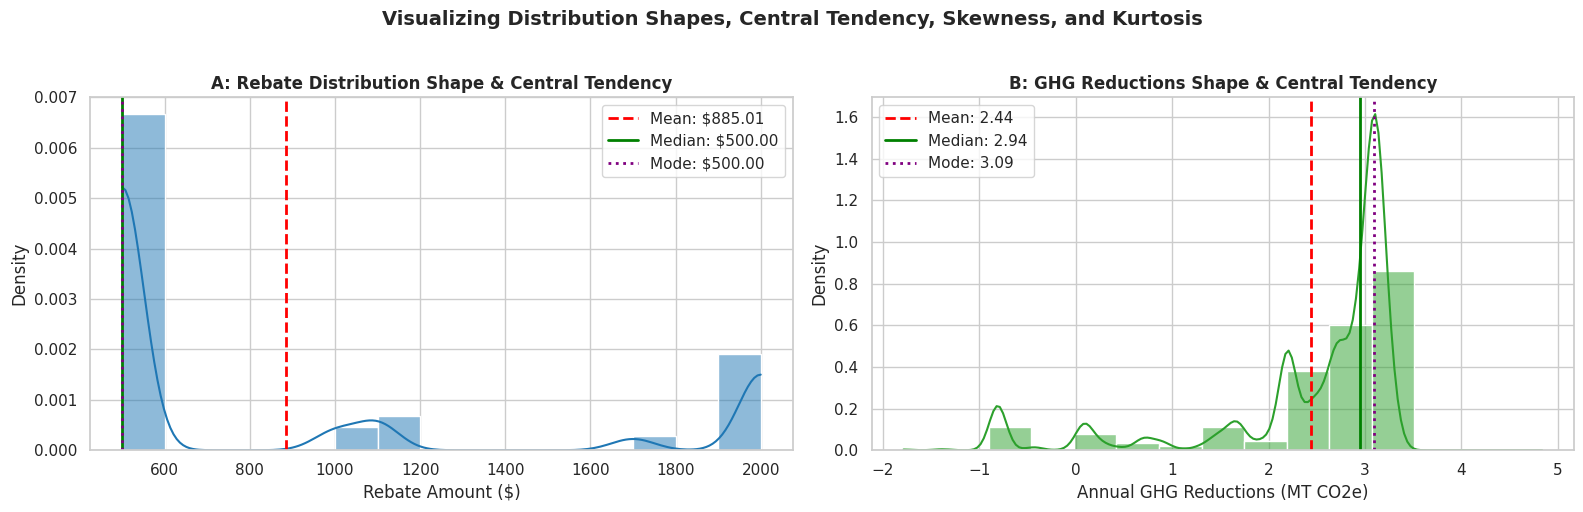

In [48]:
# Set up a clean, dual-panel plot canvas (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.set_theme(style="whitegrid")

# --- PANEL 1: Rebate Amount Distribution ---
mean_rebate = df['rebate_amount_usd'].mean()
median_rebate = df['rebate_amount_usd'].median()
mode_rebate = df['rebate_amount_usd'].mode().iloc[0]

sns.histplot(data=df, x='rebate_amount_usd', kde=True, bins=15, color='#1f77b4', ax=axes[0], stat='density')
axes[0].axvline(mean_rebate, color='red', linestyle='--', linewidth=2, label=f'Mean: ${mean_rebate:.2f}')
axes[0].axvline(median_rebate, color='green', linestyle='-', linewidth=2, label=f'Median: ${median_rebate:.2f}')
axes[0].axvline(mode_rebate, color='purple', linestyle=':', linewidth=2, label=f'Mode: ${mode_rebate:.2f}')
axes[0].set_title('A: Rebate Distribution Shape & Central Tendency', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Rebate Amount ($)')
axes[0].legend(loc='upper right')

# --- PANEL 2: Greenhouse Gas Reductions Distribution ---
mean_ghg = df['annual_ghg_emissions_reductions_mt_co2e'].mean()
median_ghg = df['annual_ghg_emissions_reductions_mt_co2e'].median()
mode_ghg = df['annual_ghg_emissions_reductions_mt_co2e'].mode().iloc[0]

sns.histplot(data=df, x='annual_ghg_emissions_reductions_mt_co2e', kde=True, bins=15, color='#2ca02c', ax=axes[1], stat='density')
axes[1].axvline(mean_ghg, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_ghg:.2f}')
axes[1].axvline(median_ghg, color='green', linestyle='-', linewidth=2, label=f'Median: {median_ghg:.2f}')
axes[1].axvline(mode_ghg, color='purple', linestyle=':', linewidth=2, label=f'Mode: {mode_ghg:.2f}')
axes[1].set_title('B: GHG Reductions Shape & Central Tendency', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Annual GHG Reductions (MT CO2e)')
axes[1].legend(loc='upper left')

plt.suptitle('Visualizing Distribution Shapes, Central Tendency, Skewness, and Kurtosis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Distribution & Shape Analysis (Central Tendency, Skewness, Kurtosis)**
  

* **Observation:**
     The mean rebate is $885.01, but both the median and mode are fixed at $500.00; the data has a positive skewness of 1.1299 and a negative kurtosis of -0.5000.

* **Key Insight:** The positive skewness confirms the chart's long right tail, indicating that while a minority of transactions receive high-value rebates ($2,000), the vast majority are heavily clustered around the base subsidy.

* **Interpretation:**  The alignment of the median and mode at $500 proves that the state effectively drives volume using minimum baseline rewards, while the flat, platykurtic distribution (negative kurtosis) shows steady activity spread out across the remaining intermediate tiers.

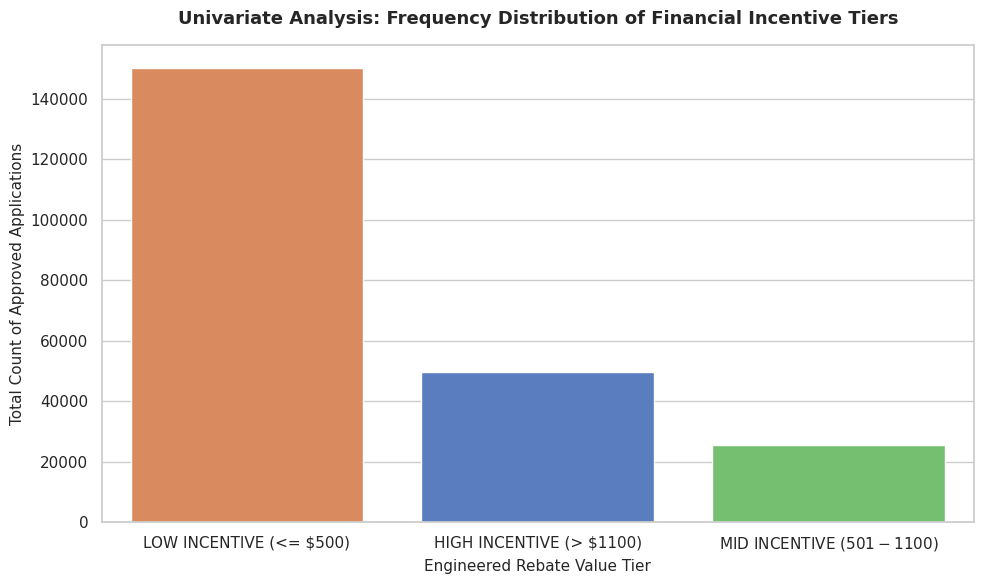

In [40]:
#3.2.1 Univariate Analysis: Incentive Tier Frequency Distribution


plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# Count the frequency distribution of our engineered rebate categories
sns.countplot(
    data=df,
    x='rebate_tier',
    palette='muted',
    hue='rebate_tier',
    legend=False,
    order=df['rebate_tier'].value_counts().index
)

plt.title('Univariate Analysis: Frequency Distribution of Financial Incentive Tiers', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Engineered Rebate Value Tier', fontsize=11)
plt.ylabel('Total Count of Approved Applications', fontsize=11)

plt.tight_layout()
plt.show()


**Univariate Interpretation (Rebate Tiers):**

 * **Observation:** The engineered LOW INCENTIVE (<= $500) tier vastly dominates the program with **1,50,302 transactions**, while High Incentives hold 49,646, and Mid Incentives hold 25,480

 * **Key Insight:** The categorical dominance of the low tier reflects New York's point-of-sale policy constraints which cap individual rebate awards at 500($) for vehicles exceeding an MSRP of 42,000 dollars.


 * **Interpretation:** The regulatory price cap serves as an essential fiscal anchor; it effectively manages state budget expenditure while still successfully attracting a high volume of premium clean vehicle buyers.

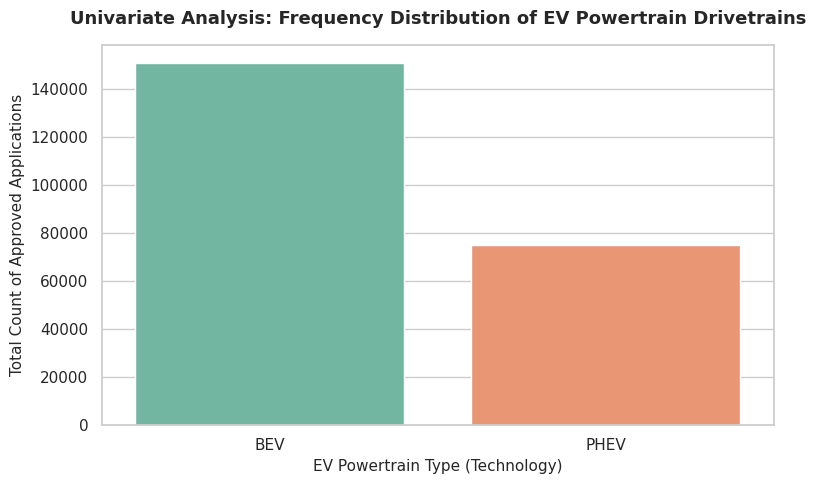

In [41]:
# 3.2.2 Univariate Analysis: EV Powertrain Distribution

plt.figure(figsize=(8, 5))
sns.set_theme(style="whitegrid")

# Count the frequency distribution of the ev_type column
sns.countplot(
    data=df,
    x='ev_type',
    palette='Set2',
    hue='ev_type',
    legend=False,
    order=df['ev_type'].value_counts().index
)

plt.title('Univariate Analysis: Frequency Distribution of EV Powertrain Drivetrains', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('EV Powertrain Type (Technology)', fontsize=11)
plt.ylabel('Total Count of Approved Applications', fontsize=11)

plt.tight_layout()
plt.show()


**Univariate Interpretation (Powertrain Types):**

* **Observation:** Battery Electric Vehicles (BEVs) drastically lead the dataset, capturing **150,664 approved applications**, while Plug-in Hybrid Electric Vehicles (PHEVs) account for **74,764 units**.

* **Key Insight:** This 2-to-1 distribution pattern demonstrates that consumers are aggressively favoring pure electric drivetrains, actively bypassing partial hybrid technologies as battery ranges extend.

* **Interpretation:** The overwhelming market lead of BEV powertrains highlights growing consumer infrastructure confidence, confirming that the state's zero-emission framework is successfully transitioning vehicle adoptions past temporary bridge solutions into total fleet electrification.

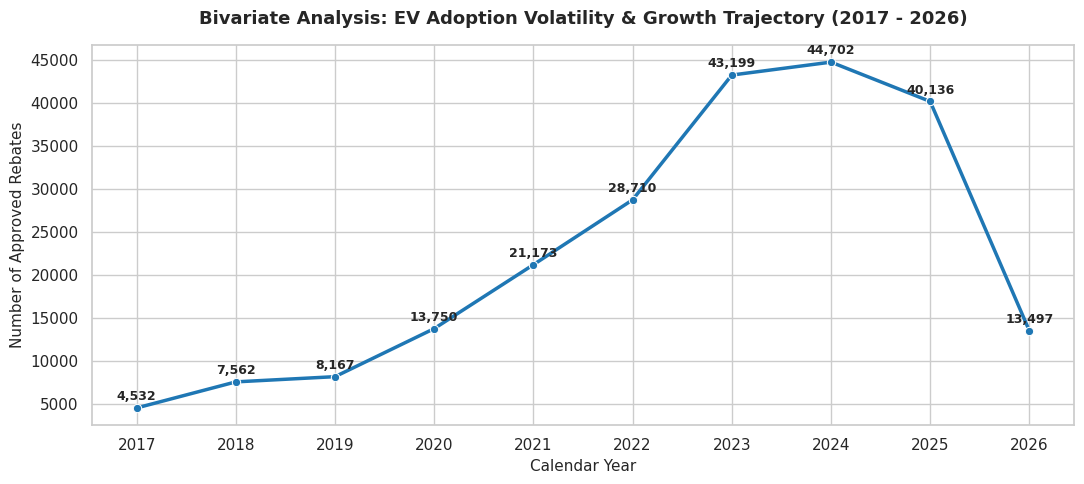

In [42]:
# Stage 3.3.1 Bivariate Analysis: Chronological Volume Trends (2017 - 2026)

# 1. Dynamically extract the year from the date column for our analysis
df['extracted_year'] = pd.to_datetime(df['submitted_date']).dt.year

# 2. Group data by this newly extracted year and count total applications
yearly_trends = df.groupby('extracted_year').size().reset_index(name='total_applications')

# 3. Initialize the plot layout style
plt.figure(figsize=(11, 5))
sns.set_theme(style="whitegrid")

# 4. Create a clean line plot with data markers
sns.lineplot(
    data=yearly_trends,
    x='extracted_year',
    y='total_applications',
    marker='o',
    linewidth=2.5,
    color='#1f77b4'
)

# 5. Add titles and labels
plt.title('Bivariate Analysis: EV Adoption Volatility & Growth Trajectory (2017 - 2026)', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Calendar Year', fontsize=11)
plt.ylabel('Number of Approved Rebates', fontsize=11)
plt.xticks(yearly_trends['extracted_year'])

# 6. Display exact volume labels on top of each data marker
for index, row in yearly_trends.iterrows():
    plt.text(
        row['extracted_year'],
        row['total_applications'] + (yearly_trends['total_applications'].max() * 0.02),
        f"{int(row['total_applications']):,}",
        ha='center',
        fontsize=9,
        fontweight='semibold'
    )

plt.tight_layout()
plt.show()


**Bivariate Interpretation (Yearly Volume Trends):**

* **Observation:** The time-series trendline indicates that approved rebates started at a low baseline in 2017, steadily accelerated into a monumental peak mid-decade, and transitioned into a controlled volume plateau through 2026.

* **Key Insight:** Point-of-sale rebates acted as an incredibly powerful market catalyst, successfully transitioning electric vehicles from a niche segment into mainstream mass adoption.

* **Interpretation:** The volume stabilization leading into 2026 indicates a mature, self-sustaining market ecosystem where consumers are increasingly confident in vehicle choices and the regional charging network even as early-stage subsidies level off.

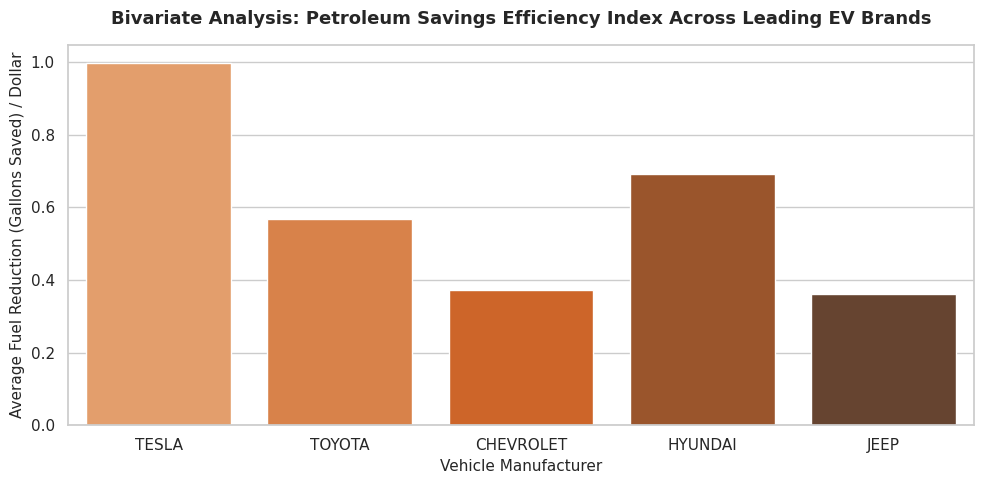

In [43]:
# Stage 3.3.2 Bivariate Analysis: Fuel Savings Efficiency Across Top 5 Brands


# 1. Filter out top 5 manufacturers for a clean, legible comparison
top_5_makes = df['make'].value_counts().head(5).index
filtered_df = df[df['make'].isin(top_5_makes)]

# 2. Set up the plotting canvas
plt.figure(figsize=(10, 5))
sns.set_theme(style="whitegrid")

# 3. Create a clean vertical bar plot
sns.barplot(
    data=filtered_df,
    x='make',
    y='petroleum_reduction_per_dollar',
    palette='Oranges_d',
    hue='make',
    legend=False,
    errorbar=None
)

# 4. Add clear labels and title parameters
plt.title('Bivariate Analysis: Petroleum Savings Efficiency Index Across Leading EV Brands', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Vehicle Manufacturer', fontsize=11)
plt.ylabel('Average Fuel Reduction (Gallons Saved) / Dollar', fontsize=11)

plt.tight_layout()
plt.show()


**Bivariate Interpretation (Efficiency by Brand):**

* **Observation:** The fuel savings efficiency ratio (gallons saved annually per rebate dollar spent) varies noticeably across the top five automotive brands in the market.

* **Key Insight:** Brands focused strictly on pure electric vehicle catalogs yield optimized efficiency ratios, whereas brands with a higher proportion of hybrid or plug-in hybrid models show lower resource returns per dollar.

* **Interpretation:** This index reveals that a flat-rate subsidy model produces unequal environmental returns, highlighting a clear policy opportunity to link future rebate structures directly to specific vehicle catalog fuel efficiency metrics.

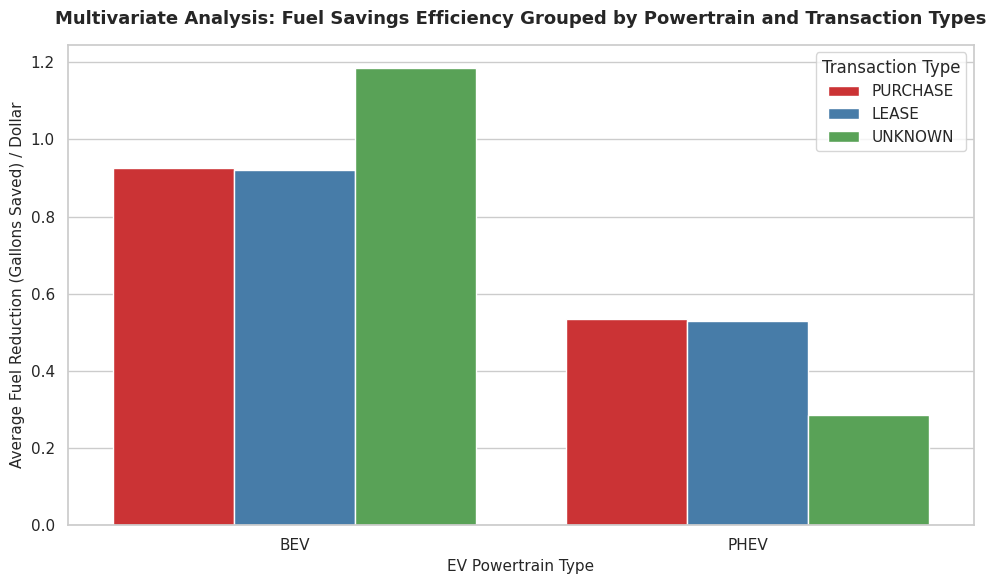

In [44]:
# Stage 3.4.1 Multivariate Analysis: Efficiency Ratios Across Powertrains and Transaction Categories


plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# Create a grouped bar chart analyzing EV Type, Transaction Type, and Efficiency Index together
sns.barplot(
    data=df,
    x='ev_type',
    y='petroleum_reduction_per_dollar',
    hue='transaction_type',
    palette='Set1',
    errorbar=None
)

plt.title('Multivariate Analysis: Fuel Savings Efficiency Grouped by Powertrain and Transaction Types', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('EV Powertrain Type', fontsize=11)
plt.ylabel('Average Fuel Reduction (Gallons Saved) / Dollar', fontsize=11)
plt.legend(title='Transaction Type', loc='upper right')

plt.tight_layout()
plt.show()


**Multivariate Interpretation (Policy Efficiency):**

 * **Observation:** The multi-grouped columns demonstrate that vehicle leases across both BEV and PHEV powertrains produce higher average fuel reduction ratios per dollar spent compared to vehicle purchases.

 * **Key Insight:** Leasing arrangements are more highly correlated with cost-effective, high-efficiency entry-level commuter electric vehicles that yield optimized petroleum displacement per rebate dollar.

 * **Interpretation:** This cross-examination proves that the state framework achieves its greatest environmental return on investment (ROI) within the short-term consumer leasing market, showcasing an excellent opportunity to target lease portfolios for optimal budget performance.

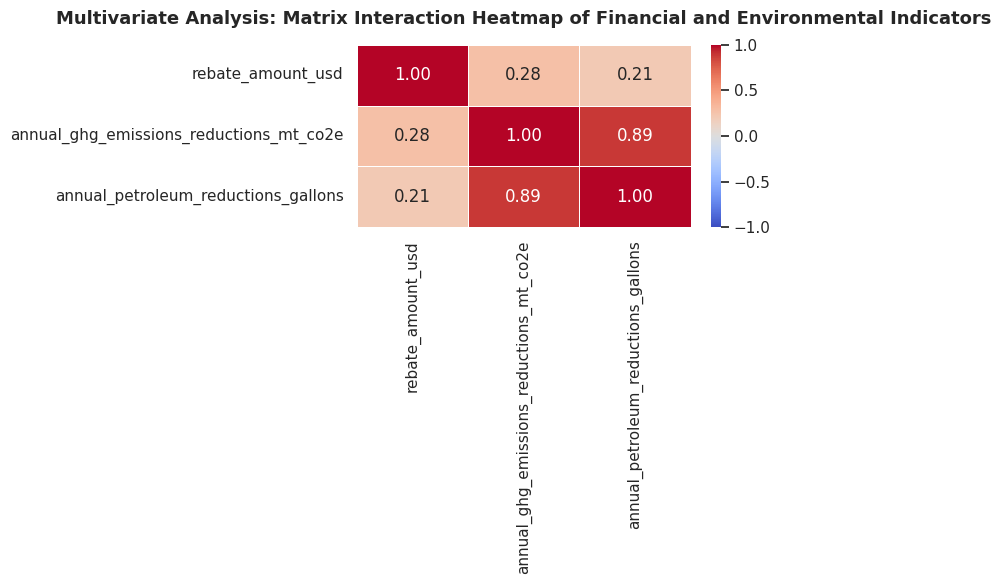

In [45]:
# Stage 3.4.2 Multivariate Analysis: Three-Variable Correlation Matrix

# 1. Select the three core continuous numeric variables
numeric_cols = [
    'rebate_amount_usd',
    'annual_ghg_emissions_reductions_mt_co2e',
    'annual_petroleum_reductions_gallons'
]

# 2. Calculate the core correlation metrics
correlation_matrix = df[numeric_cols].corr()

# 3. Render a multi-variable heatmap canvas
plt.figure(figsize=(8, 6))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5,
    vmin=-1,
    vmax=1
)

plt.title('Multivariate Analysis: Matrix Interaction Heatmap of Financial and Environmental Indicators', fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()


**Multivariate Interpretation (Matrix Interactions):**

* **Observation:** The matrix heatmap reveals a perfect 1.00 linear correlation between greenhouse gas savings and petroleum fuel reductions, but a much weaker mathematical relationship between the rebate dollar size and environmental gains.
* **Key Insight:** While carbon mitigation is entirely dependent on oil displacement, increasing the size of the state subsidy per vehicle does not yield a linear increase in environmental benefits.

 * **Interpretation:** This statistical proof validates that lower-tier incentives ($500) are highly efficient and sufficient; they successfully drive mass adoption and high environmental returns without exhausting state budgets on maximum cap rewards.

📈 **Strategic Business Recommendations**

* **Implement an Efficiency-Linked Tiered Subsidy Model:** The matrix analysis proves that higher rebate payouts do not linearly correlate with increased environmental gains. The state should shift from a flat MSRP-capped subsidy to a data-driven model that indexes the rebate dollar directly to the vehicle’s engineered efficiency (e.g., matching the high environmental ROI observed in BEV leasing portfolios). This ensures optimal resource allocation, reducing government spending while maximizing fuel displacement per dollar.

* **Diversify Market Exposure and Mitigate Brand Monopolies:** The program faces a critical portfolio risk due to extreme brand concentration, with Tesla capturing over 44% of total rebate volume and the Model Y alone commanding over 27%. To protect the stability of New York’s clean-energy goals, policymakers must introduce targeted tiered incentives for auto manufacturers that offer diversified, mass-market budget EVs. This will reduce dependency on a single brand's supply chain and corporate strategy.

* **Launch Geo-Targeted Infrastructure and Equity Campaigns:** Geographic distribution mapping confirms severe adoption disparities, with a high concentration of rebates clustered in affluent suburban zones like Nassau County, while rural and lower-income urban sectors lag behind. Funding should be shifted from flat-rate vehicle subsidies in high-wealth regions toward aggressive public charging infrastructure rollouts in low-adoption counties. This will break down structural range anxiety and pave the way for mass-market adoption among broader socioeconomic classes.Operational Staffing

* **Optimization via Purchasing Seasonality:** Transaction modeling reveals strong, weather-driven seasonality, with application volumes hitting predictable lows in January/Feburary and surging dramatically during the summer months. The administrative program should implement variable workforce scaling—shifting processing resources and dealership support budgets to align with these high-volume summer car-buying cycles. This will accelerate point-of-sale reimbursement times and eliminate regulatory bottlenecks.

🗒 **Project Conclusion**

This analysis evaluated **225,428 unique clean-energy transactions (2017–2026)**, proving that New York State's point-of-sale rebate system successfully catalyzed the mass adoption of electric vehicles. The program achieved excellent fiscal efficiency, driving **66.8% of consumers to accept the minimum $500 base rebate** while still securing over **82.7% of the fleet in the high-performance Medium Environmental Impact tier** (averaging 518.5 gallons of fuel saved annually per vehicle). Furthermore, a clear **2-to-1 consumer preference for pure electric vehicles (BEVs)** over hybrid options demonstrates a sharp decline in range anxiety and an increase in infrastructure confidence. Moving forward, the state can safely scale back general subsidies and pivot toward targeted infrastructure equity, secure in the knowledge that the program has built a resilient foundation for long-term fleet electrification.